In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/chethuhn/network-intrusion-dataset/Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv
/kaggle/input/datasets/chethuhn/network-intrusion-dataset/Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv
/kaggle/input/datasets/chethuhn/network-intrusion-dataset/Tuesday-WorkingHours.pcap_ISCX.csv
/kaggle/input/datasets/chethuhn/network-intrusion-dataset/Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv
/kaggle/input/datasets/chethuhn/network-intrusion-dataset/Monday-WorkingHours.pcap_ISCX.csv
/kaggle/input/datasets/chethuhn/network-intrusion-dataset/Friday-WorkingHours-Morning.pcap_ISCX.csv
/kaggle/input/datasets/chethuhn/network-intrusion-dataset/Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv
/kaggle/input/datasets/chethuhn/network-intrusion-dataset/Wednesday-workingHours.pcap_ISCX.csv


In [2]:
#imports 
import os, sys, glob, gc, time, json, joblib, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, f1_score, roc_auc_score
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import LinearSVC, SVC
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import make_pipeline

from imblearn.over_sampling import SMOTE

from xgboost import XGBClassifier

In [4]:
INPUT_DIR = '/kaggle/input/datasets/chethuhn/network-intrusion-dataset'
OUTPUT_DIR = '/kaggle/working/'
os.makedirs(OUTPUT_DIR, exist_ok=True)

all_csvs = glob.glob(os.path.join(INPUT_DIR, '**', '*.csv'), recursive=True)
print(f"Found {len(all_csvs)} CSV files:")

for f in sorted(all_csvs):
    size_mb = os.path.getsize(f) / 1e6
    print(f"  {os.path.basename(f):<50} {size_mb:6.1f} MB")

Found 8 CSV files:
  Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv     77.1 MB
  Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv   76.9 MB
  Friday-WorkingHours-Morning.pcap_ISCX.csv            58.3 MB
  Monday-WorkingHours.pcap_ISCX.csv                   176.9 MB
  Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv   83.1 MB
  Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv   52.0 MB
  Tuesday-WorkingHours.pcap_ISCX.csv                  135.1 MB
  Wednesday-workingHours.pcap_ISCX.csv                225.2 MB


In [6]:
# Load all CSVs and concatenate into a single dataframe
dfs = []
for f in sorted(all_csvs):
    tmp = pd.read_csv(f, low_memory=False)
    tmp.columns = tmp.columns.str.strip()
    dfs.append(tmp)
    print(f"Loaded {os.path.basename(f)} -> {tmp.shape}")

df = pd.concat(dfs, ignore_index=True)
print(f"\nCombined df shape: {df.shape}")

# Clean label column
label_col = ' Label' if ' Label' in df.columns else 'Label'
df.rename(columns={label_col: 'Label'}, inplace=True)
df['Label'] = df['Label'].str.strip()

print("\nLabel value counts:")
print(df['Label'].value_counts())

Loaded Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv -> (225745, 79)
Loaded Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv -> (286467, 79)
Loaded Friday-WorkingHours-Morning.pcap_ISCX.csv -> (191033, 79)
Loaded Monday-WorkingHours.pcap_ISCX.csv -> (529918, 79)
Loaded Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv -> (288602, 79)
Loaded Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv -> (170366, 79)
Loaded Tuesday-WorkingHours.pcap_ISCX.csv -> (445909, 79)
Loaded Wednesday-workingHours.pcap_ISCX.csv -> (692703, 79)

Combined df shape: (2830743, 79)

Label value counts:
Label
BENIGN                        2273097
DoS Hulk                       231073
PortScan                       158930
DDoS                           128027
DoS GoldenEye                   10293
FTP-Patator                      7938
SSH-Patator                      5897
DoS slowloris                    5796
DoS Slowhttptest                 5499
Bot                              1966
Web Attack

In [7]:
print("  DATASET OVERVIEW")
print(f"  df.shape  -> {df.shape}")
print(f"  df.size   -> {df.size:,}  (rows x columns)")
print(f"  RAM usage -> {df.memory_usage(deep=True).sum()/1e6:.1f} MB")
print(f"\nAll {df.shape[1]} columns:")
for i, c in enumerate(df.columns):
    print(f"  [{i:3d}] {c}")

  DATASET OVERVIEW
  df.shape  -> (2830743, 79)
  df.size   -> 223,628,697  (rows x columns)
  RAM usage -> 1922.9 MB

All 79 columns:
  [  0] Destination Port
  [  1] Flow Duration
  [  2] Total Fwd Packets
  [  3] Total Backward Packets
  [  4] Total Length of Fwd Packets
  [  5] Total Length of Bwd Packets
  [  6] Fwd Packet Length Max
  [  7] Fwd Packet Length Min
  [  8] Fwd Packet Length Mean
  [  9] Fwd Packet Length Std
  [ 10] Bwd Packet Length Max
  [ 11] Bwd Packet Length Min
  [ 12] Bwd Packet Length Mean
  [ 13] Bwd Packet Length Std
  [ 14] Flow Bytes/s
  [ 15] Flow Packets/s
  [ 16] Flow IAT Mean
  [ 17] Flow IAT Std
  [ 18] Flow IAT Max
  [ 19] Flow IAT Min
  [ 20] Fwd IAT Total
  [ 21] Fwd IAT Mean
  [ 22] Fwd IAT Std
  [ 23] Fwd IAT Max
  [ 24] Fwd IAT Min
  [ 25] Bwd IAT Total
  [ 26] Bwd IAT Mean
  [ 27] Bwd IAT Std
  [ 28] Bwd IAT Max
  [ 29] Bwd IAT Min
  [ 30] Fwd PSH Flags
  [ 31] Bwd PSH Flags
  [ 32] Fwd URG Flags
  [ 33] Bwd URG Flags
  [ 34] Fwd Header Lengt

---
## EDA — 15 Visualisations

1. Label distribution — bar chart & pie chart
2. Binary split (BENIGN vs ATTACK) + attack breakdown
3. Histograms of first 16 numeric features
4. Boxplots — key features by label
5. Correlation heatmap (top 20 features)
6. Feature correlation with target (|Pearson r|)
7. Violin plots — key features by label
8. Scatter — Flow Packets/s vs Flow Bytes/s
9. TCP flag counts by attack type
10. KDE — Flow Duration (BENIGN vs ATTACK)
11. Top 20 destination ports
12. Pairplot of key features
13. Class imbalance stacked bar (% of total)
14. Mean packet lengths — BENIGN vs ATTACK
15. IAT (Inter-Arrival Time) KDE by label

In [8]:
# ── EDA Setup ──────────────────────────────────────────────────────────────
warnings.filterwarnings('ignore')
sns.set_theme(style='darkgrid', palette='muted')
PLOT_DIR = os.path.join(OUTPUT_DIR, 'eda_plots')
os.makedirs(PLOT_DIR, exist_ok=True)

# Binary label: BENIGN=0, ATTACK=1
df['binary_label'] = (df['Label'] != 'BENIGN').astype(int)

# Numeric columns only
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
if 'binary_label' in num_cols:
    num_cols.remove('binary_label')

print(f"Total numeric features: {len(num_cols)}")
print(f"Class distribution:\n{df['binary_label'].value_counts()}")

Total numeric features: 78
Class distribution:
binary_label
0    2273097
1     557646
Name: count, dtype: int64


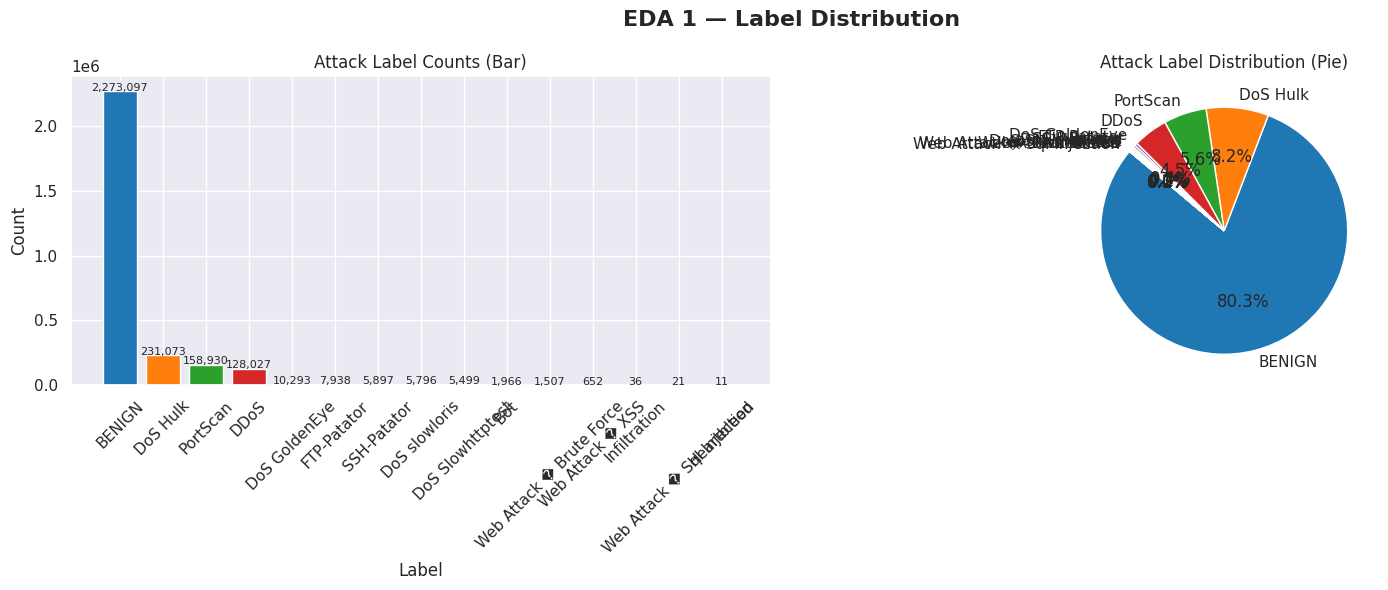

EDA 1 complete.


In [9]:
# ── EDA 1: Label Distribution — Bar Chart & Pie Chart ─────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('EDA 1 — Label Distribution', fontsize=16, fontweight='bold')

label_counts = df['Label'].value_counts()

# Bar chart
axes[0].bar(label_counts.index, label_counts.values,
            color=sns.color_palette('tab10', len(label_counts)))
axes[0].set_title('Attack Label Counts (Bar)')
axes[0].set_xlabel('Label')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=45)
for i, v in enumerate(label_counts.values):
    axes[0].text(i, v + 500, f'{v:,}', ha='center', fontsize=8)

# Pie chart
axes[1].pie(label_counts.values, labels=label_counts.index,
            autopct='%1.1f%%', startangle=140,
            colors=sns.color_palette('tab10', len(label_counts)))
axes[1].set_title('Attack Label Distribution (Pie)')

plt.tight_layout()
plt.savefig(os.path.join(PLOT_DIR, 'eda_01_label_distribution.png'), dpi=150, bbox_inches='tight')
plt.show()
print('EDA 1 complete.')

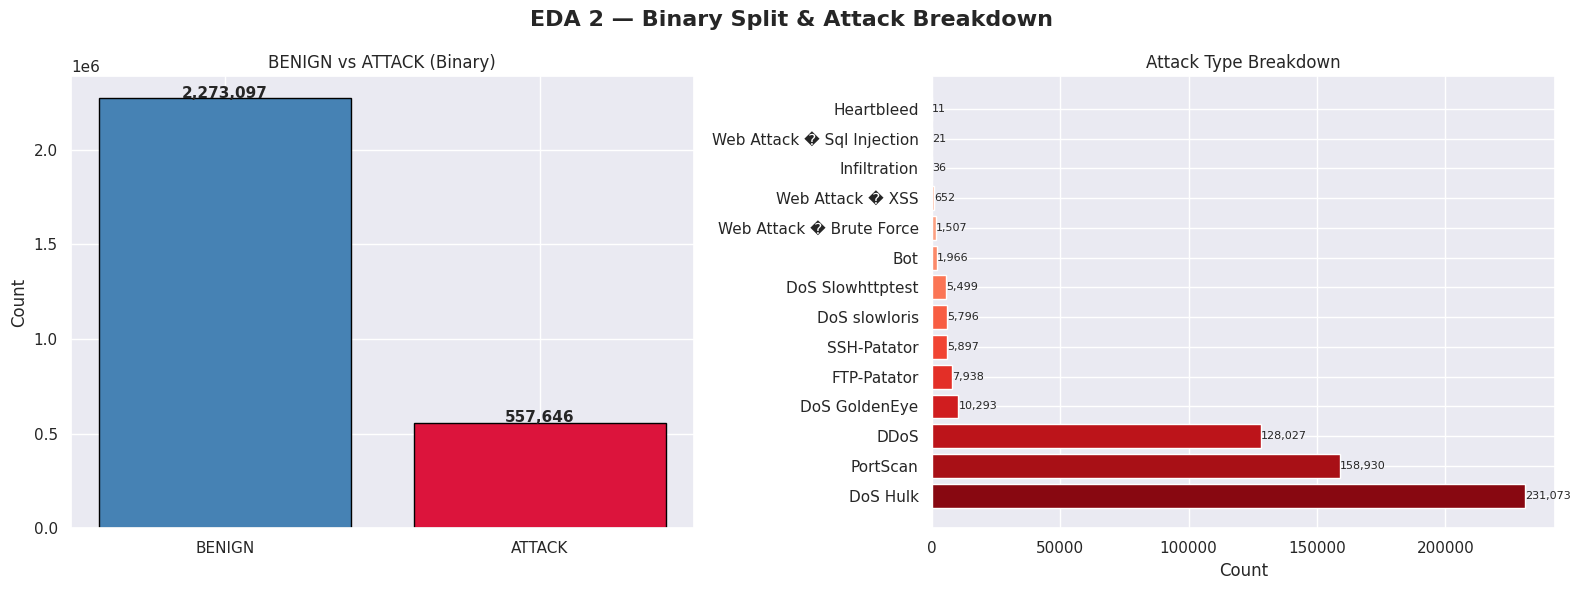

EDA 2 complete.


In [10]:
# ── EDA 2: Binary Split (BENIGN vs ATTACK) + Attack Breakdown ──────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('EDA 2 — Binary Split & Attack Breakdown', fontsize=16, fontweight='bold')

binary_counts = df['binary_label'].value_counts().rename({0: 'BENIGN', 1: 'ATTACK'})
axes[0].bar(binary_counts.index, binary_counts.values,
            color=['steelblue', 'crimson'], edgecolor='black')
axes[0].set_title('BENIGN vs ATTACK (Binary)')
axes[0].set_ylabel('Count')
for i, v in enumerate(binary_counts.values):
    axes[0].text(i, v + 1000, f'{v:,}', ha='center', fontsize=11, fontweight='bold')

# Attack-only breakdown
attack_counts = df[df['Label'] != 'BENIGN']['Label'].value_counts()
axes[1].barh(attack_counts.index, attack_counts.values,
             color=sns.color_palette('Reds_r', len(attack_counts)))
axes[1].set_title('Attack Type Breakdown')
axes[1].set_xlabel('Count')
for i, v in enumerate(attack_counts.values):
    axes[1].text(v + 100, i, f'{v:,}', va='center', fontsize=8)

plt.tight_layout()
plt.savefig(os.path.join(PLOT_DIR, 'eda_02_binary_split.png'), dpi=150, bbox_inches='tight')
plt.show()
print('EDA 2 complete.')

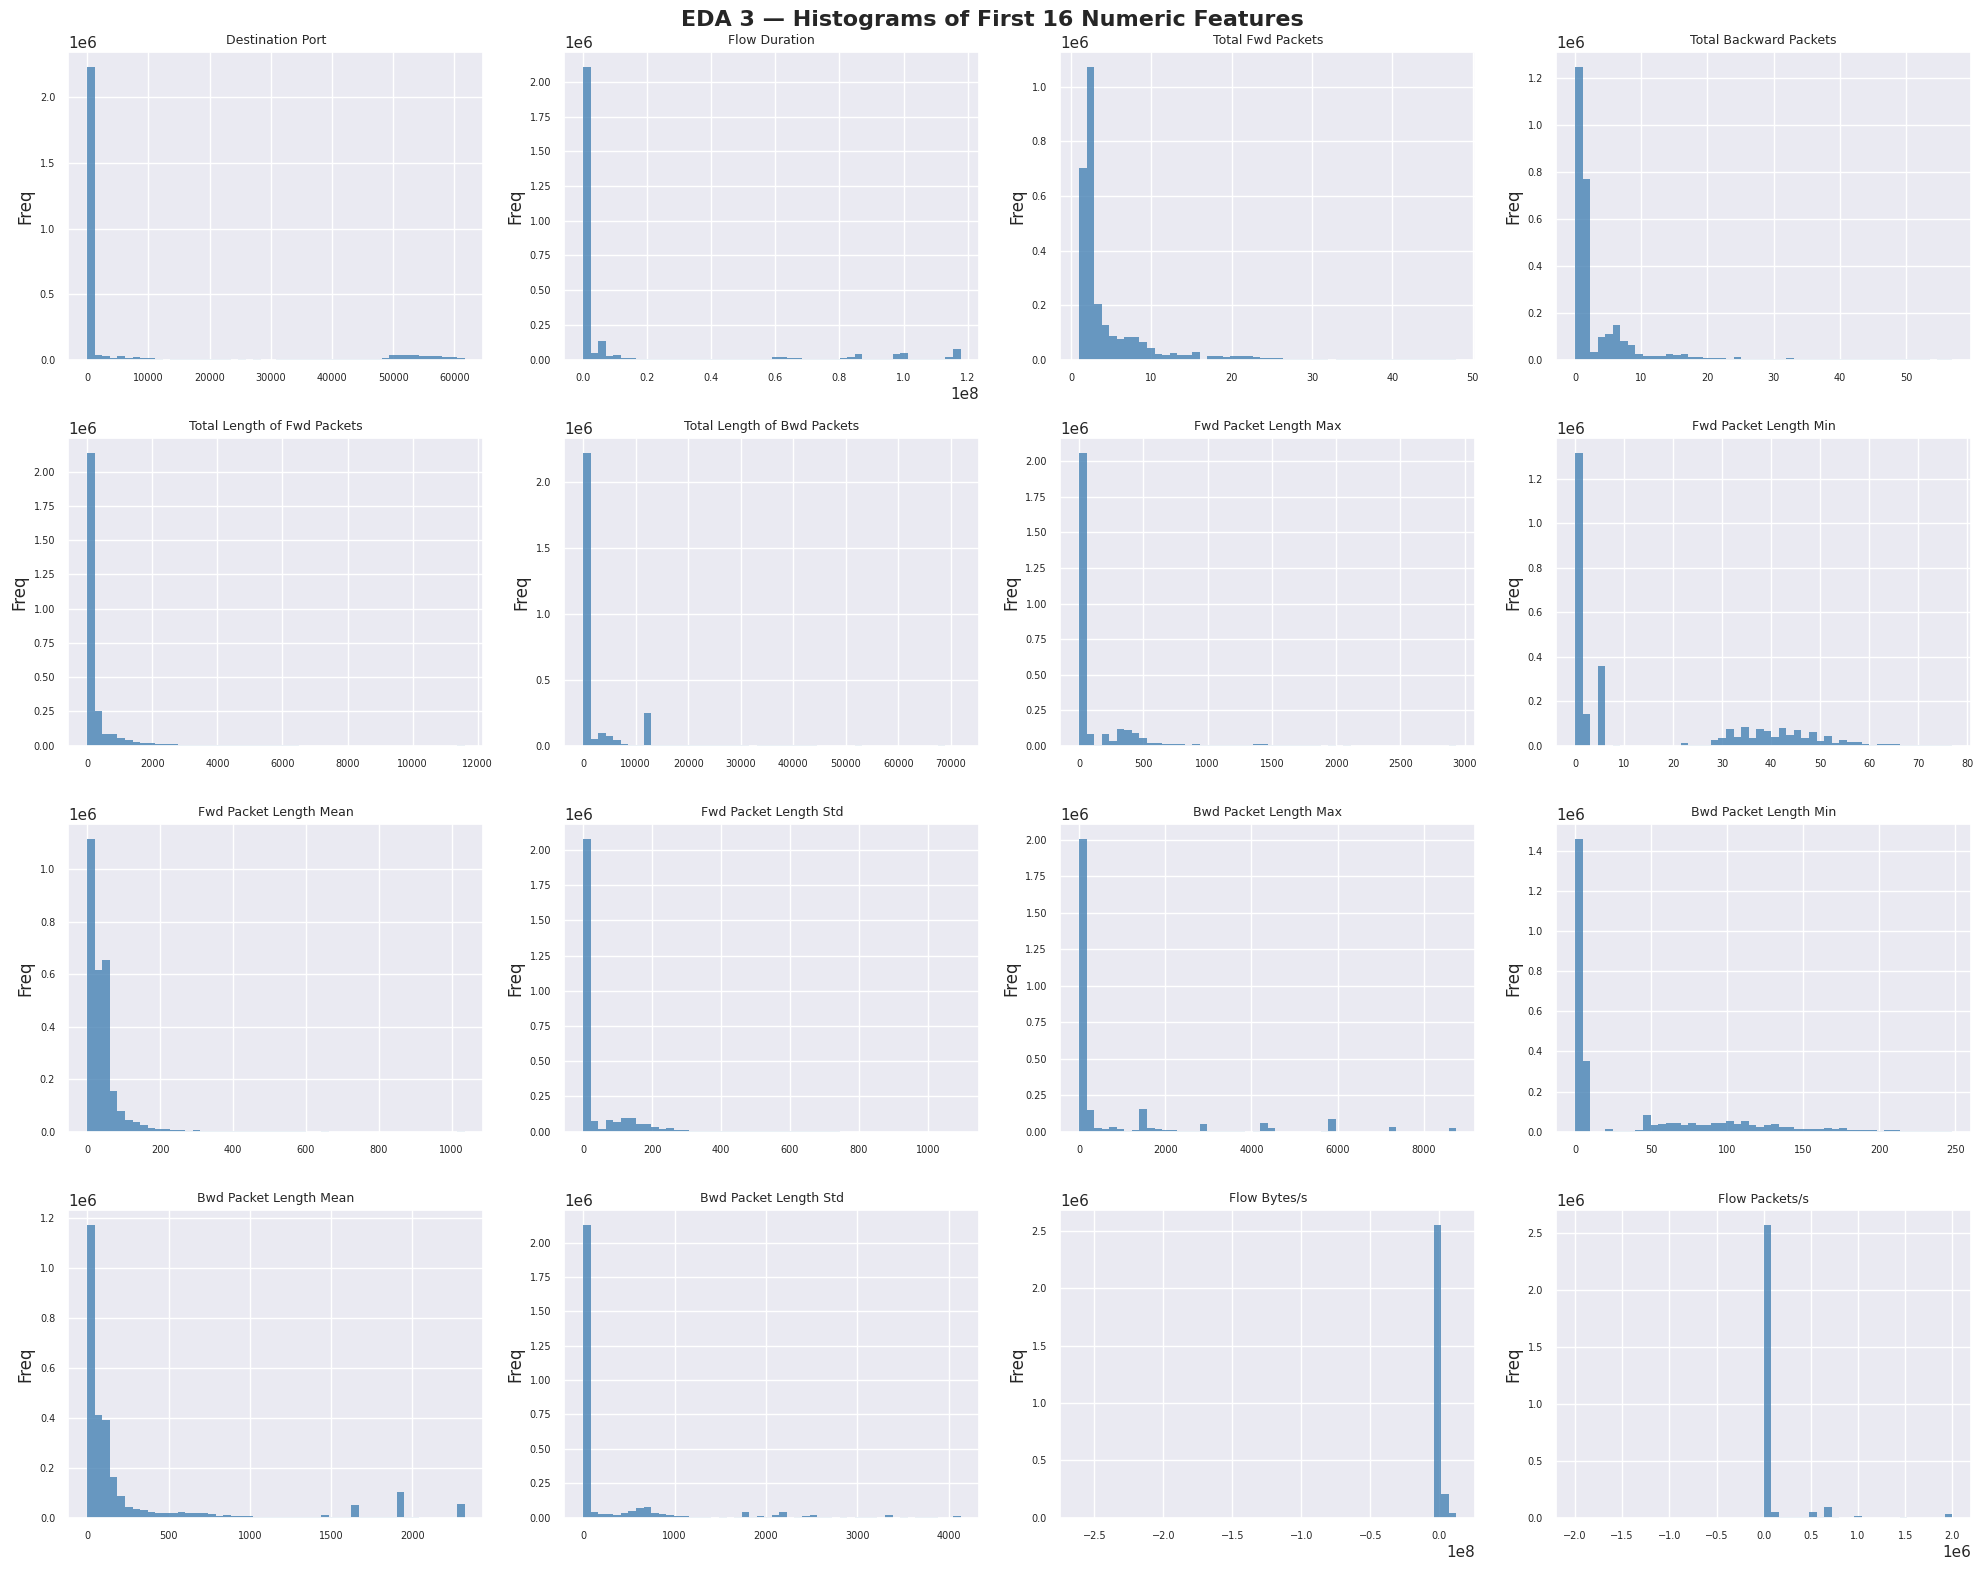

EDA 3 complete.


In [11]:
# ── EDA 3: Histograms of First 16 Numeric Features ────────────────────────
feat16 = num_cols[:16]
fig, axes = plt.subplots(4, 4, figsize=(20, 16))
fig.suptitle('EDA 3 — Histograms of First 16 Numeric Features', fontsize=16, fontweight='bold')

for ax, col in zip(axes.flatten(), feat16):
    data = df[col].replace([np.inf, -np.inf], np.nan).dropna()
    # Clip to 99th percentile to avoid extreme outlier distortion
    upper = data.quantile(0.99)
    data = data[data <= upper]
    ax.hist(data, bins=50, color='steelblue', edgecolor='none', alpha=0.8)
    ax.set_title(col, fontsize=9)
    ax.set_xlabel('')
    ax.set_ylabel('Freq')
    ax.tick_params(labelsize=7)

plt.tight_layout()
plt.savefig(os.path.join(PLOT_DIR, 'eda_03_histograms.png'), dpi=150, bbox_inches='tight')
plt.show()
print('EDA 3 complete.')

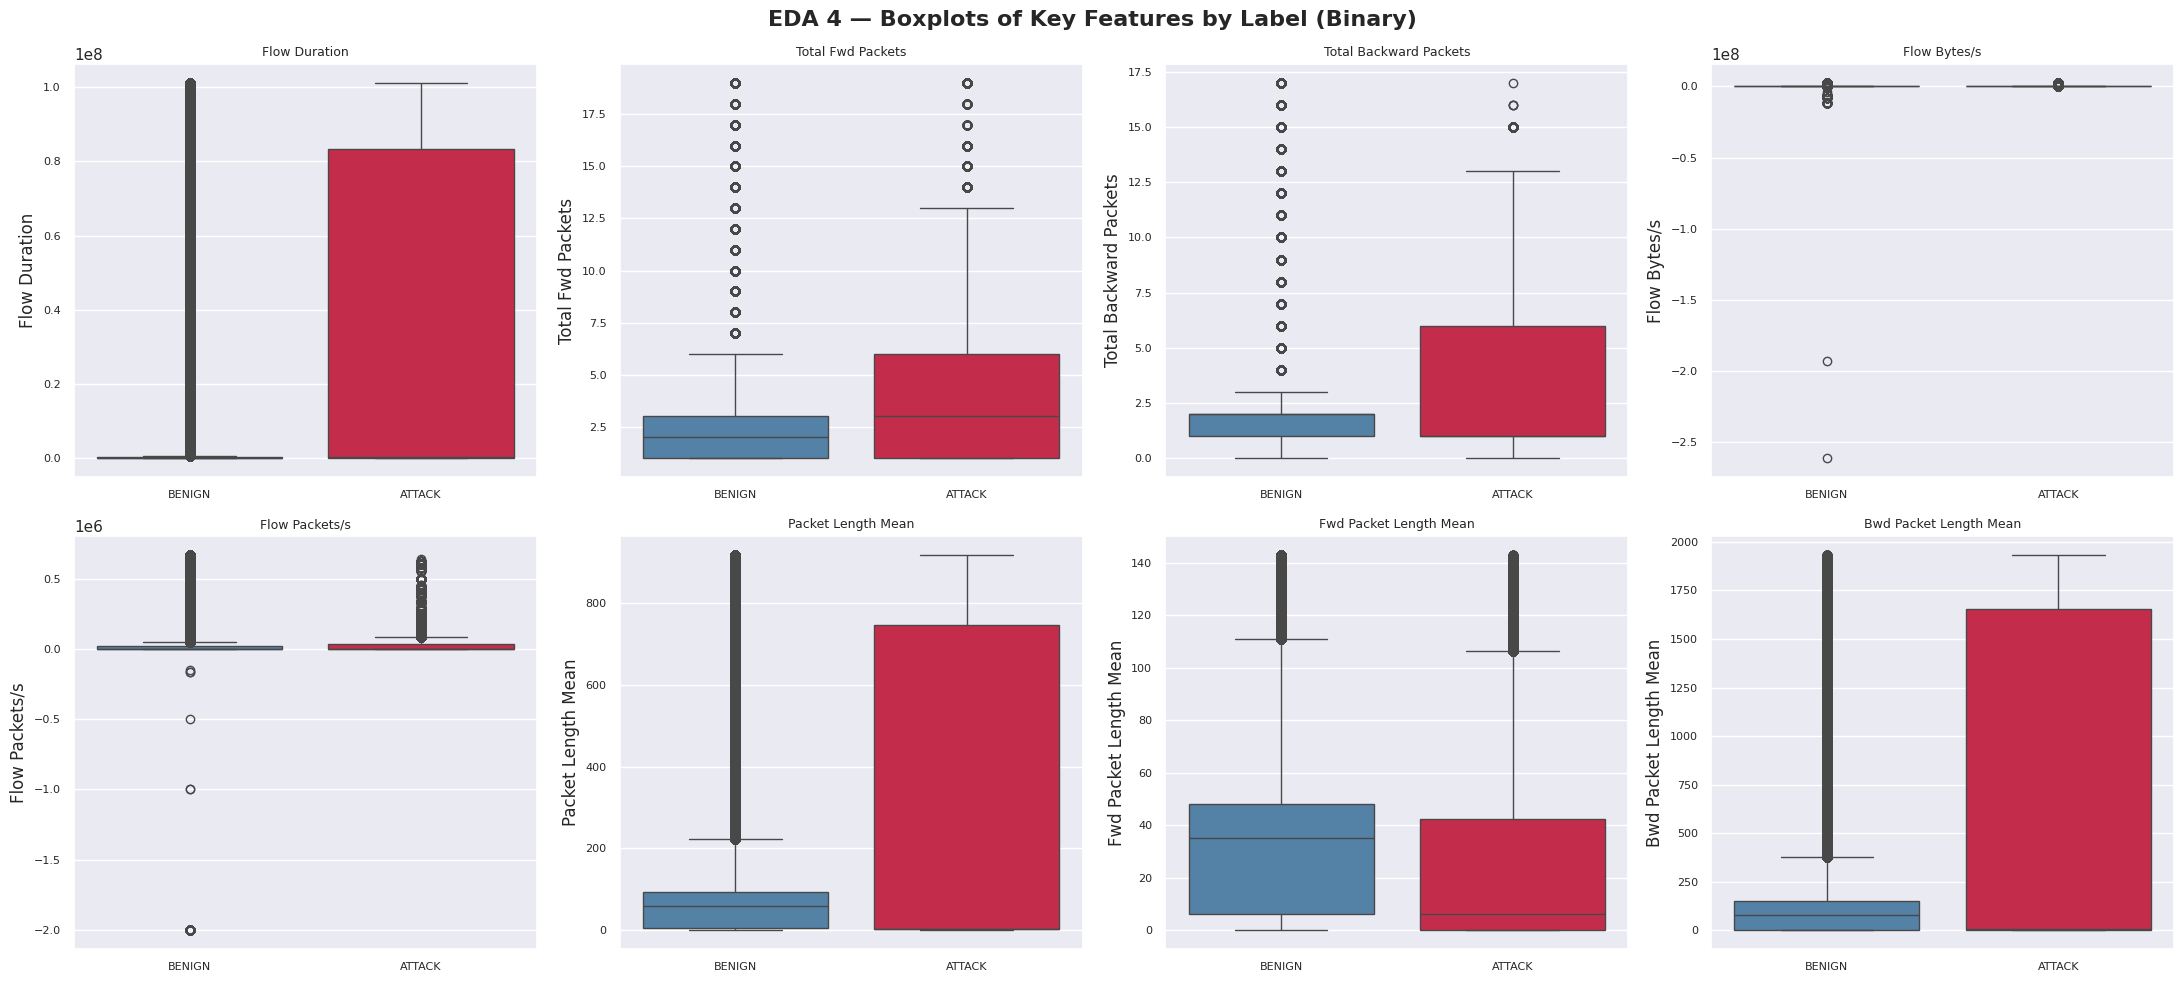

EDA 4 complete.


In [12]:
# ── EDA 4: Boxplots — Key Features by Label ───────────────────────────────
KEY_FEATURES = [
    'Flow Duration', 'Total Fwd Packets', 'Total Backward Packets',
    'Flow Bytes/s', 'Flow Packets/s', 'Packet Length Mean',
    'Fwd Packet Length Mean', 'Bwd Packet Length Mean'
]
# Use only features that actually exist in df
key_feats = [f for f in KEY_FEATURES if f in df.columns][:8]

fig, axes = plt.subplots(2, 4, figsize=(22, 10))
fig.suptitle('EDA 4 — Boxplots of Key Features by Label (Binary)', fontsize=16, fontweight='bold')

plot_df = df[key_feats + ['binary_label']].replace([np.inf, -np.inf], np.nan).dropna()
plot_df['binary_label'] = plot_df['binary_label'].map({0: 'BENIGN', 1: 'ATTACK'})

for ax, col in zip(axes.flatten(), key_feats):
    upper = plot_df[col].quantile(0.95)
    tmp = plot_df[plot_df[col] <= upper]
    sns.boxplot(data=tmp, x='binary_label', y=col, ax=ax,
                palette={'BENIGN': 'steelblue', 'ATTACK': 'crimson'})
    ax.set_title(col, fontsize=9)
    ax.set_xlabel('')
    ax.tick_params(labelsize=8)

plt.tight_layout()
plt.savefig(os.path.join(PLOT_DIR, 'eda_04_boxplots.png'), dpi=150, bbox_inches='tight')
plt.show()
print('EDA 4 complete.')

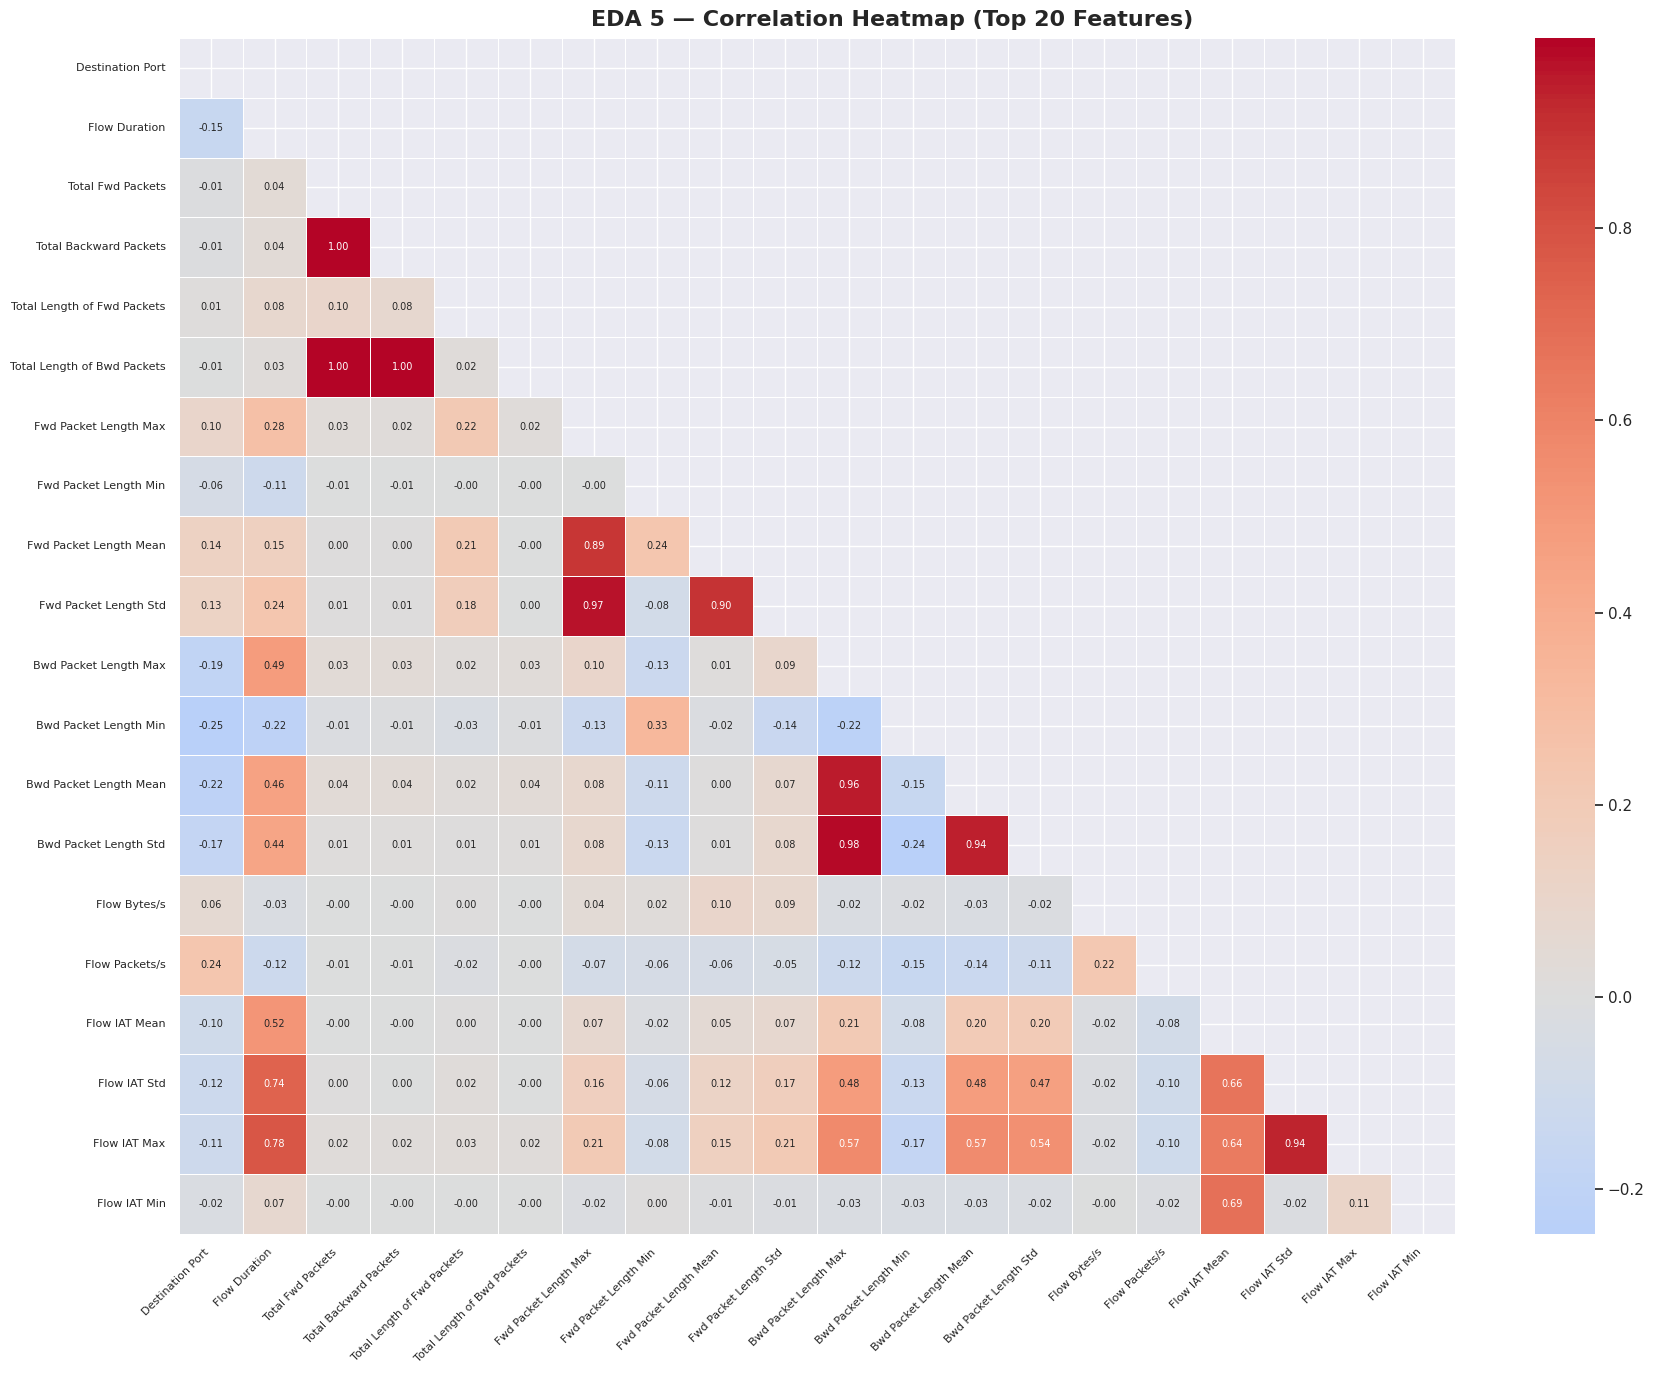

EDA 5 complete.


In [13]:
# ── EDA 5: Correlation Heatmap (Top 20 Features) ─────────────────────────
top20 = num_cols[:20]
corr_df = df[top20].replace([np.inf, -np.inf], np.nan).dropna().sample(min(50000, len(df)), random_state=42)

fig, ax = plt.subplots(figsize=(18, 14))
fig.suptitle('EDA 5 — Correlation Heatmap (Top 20 Features)', fontsize=16, fontweight='bold')

corr_matrix = corr_df.corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f',
            cmap='coolwarm', center=0, linewidths=0.5,
            ax=ax, annot_kws={'size': 7})
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right', fontsize=8)
ax.set_yticklabels(ax.get_yticklabels(), fontsize=8)

plt.tight_layout()
plt.savefig(os.path.join(PLOT_DIR, 'eda_05_correlation_heatmap.png'), dpi=150, bbox_inches='tight')
plt.show()
print('EDA 5 complete.')

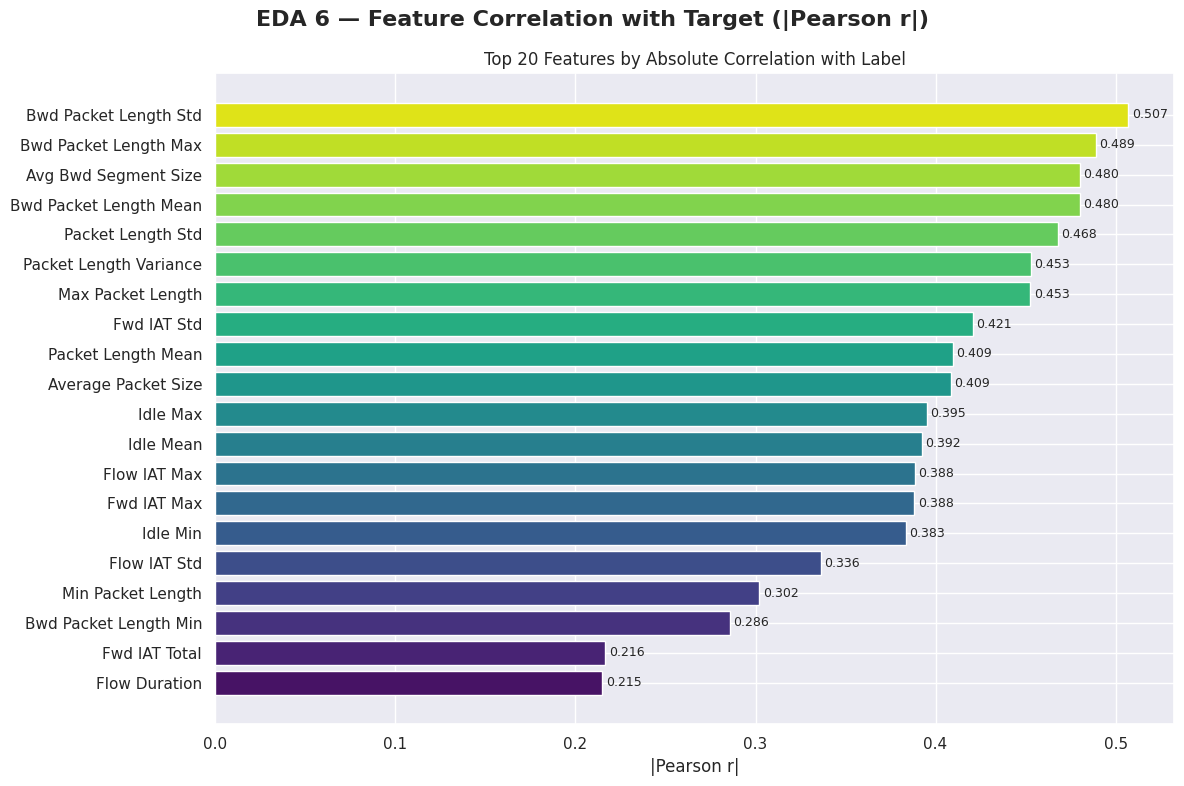

EDA 6 complete.


In [14]:
# ── EDA 6: Feature Correlation with Target (|Pearson r|) ─────────────────
sample = df[num_cols + ['binary_label']].replace([np.inf, -np.inf], np.nan).dropna()
sample = sample.sample(min(100000, len(sample)), random_state=42)

corr_target = sample.corr()['binary_label'].drop('binary_label').abs().sort_values(ascending=False)
top_corr = corr_target.head(20)

fig, ax = plt.subplots(figsize=(12, 8))
fig.suptitle('EDA 6 — Feature Correlation with Target (|Pearson r|)', fontsize=16, fontweight='bold')

bars = ax.barh(top_corr.index[::-1], top_corr.values[::-1],
               color=sns.color_palette('viridis', len(top_corr)))
ax.set_xlabel('|Pearson r|')
ax.set_title('Top 20 Features by Absolute Correlation with Label')
for bar, val in zip(bars, top_corr.values[::-1]):
    ax.text(val + 0.002, bar.get_y() + bar.get_height()/2,
            f'{val:.3f}', va='center', fontsize=9)

plt.tight_layout()
plt.savefig(os.path.join(PLOT_DIR, 'eda_06_feature_target_corr.png'), dpi=150, bbox_inches='tight')
plt.show()
print('EDA 6 complete.')

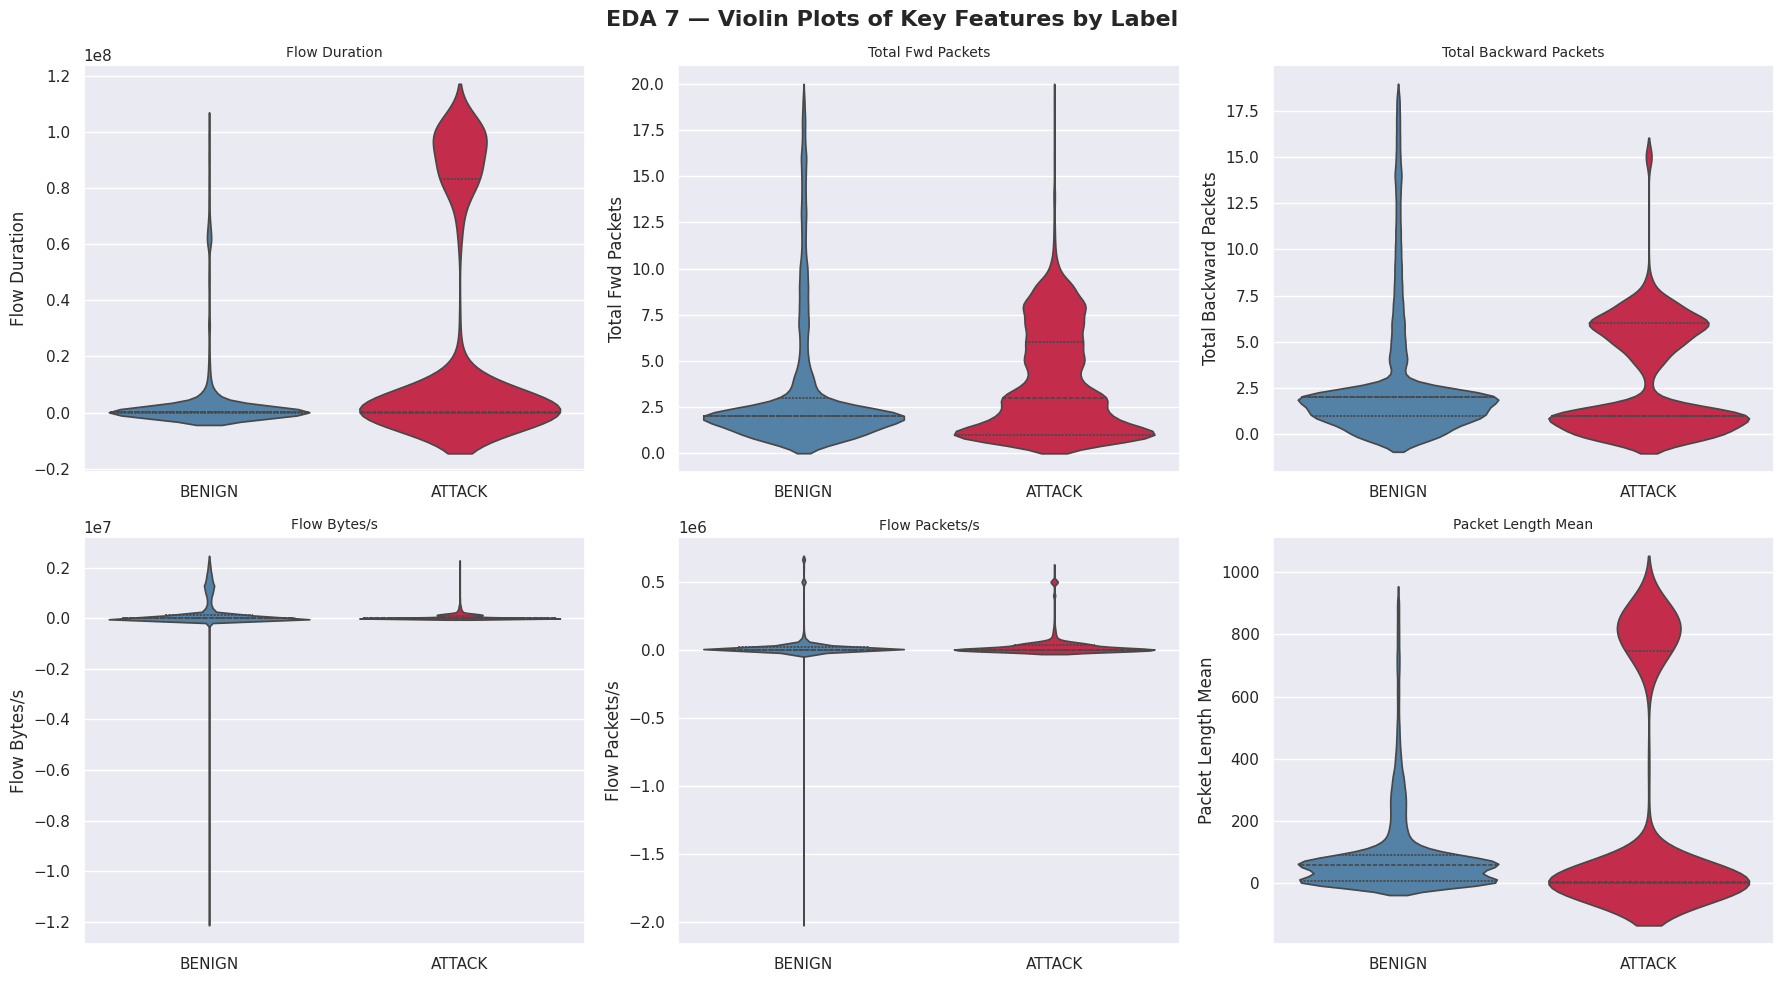

EDA 7 complete.


In [15]:
# ── EDA 7: Violin Plots — Key Features by Label ───────────────────────────
violin_feats = [f for f in KEY_FEATURES if f in df.columns][:6]

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('EDA 7 — Violin Plots of Key Features by Label', fontsize=16, fontweight='bold')

plot_df = df[violin_feats + ['binary_label']].replace([np.inf, -np.inf], np.nan).dropna()
plot_df['binary_label'] = plot_df['binary_label'].map({0: 'BENIGN', 1: 'ATTACK'})
plot_df = plot_df.sample(min(30000, len(plot_df)), random_state=42)

for ax, col in zip(axes.flatten(), violin_feats):
    upper = plot_df[col].quantile(0.95)
    tmp = plot_df[plot_df[col] <= upper]
    sns.violinplot(data=tmp, x='binary_label', y=col, ax=ax,
                   palette={'BENIGN': 'steelblue', 'ATTACK': 'crimson'},
                   inner='quartile')
    ax.set_title(col, fontsize=10)
    ax.set_xlabel('')

plt.tight_layout()
plt.savefig(os.path.join(PLOT_DIR, 'eda_07_violin_plots.png'), dpi=150, bbox_inches='tight')
plt.show()
print('EDA 7 complete.')

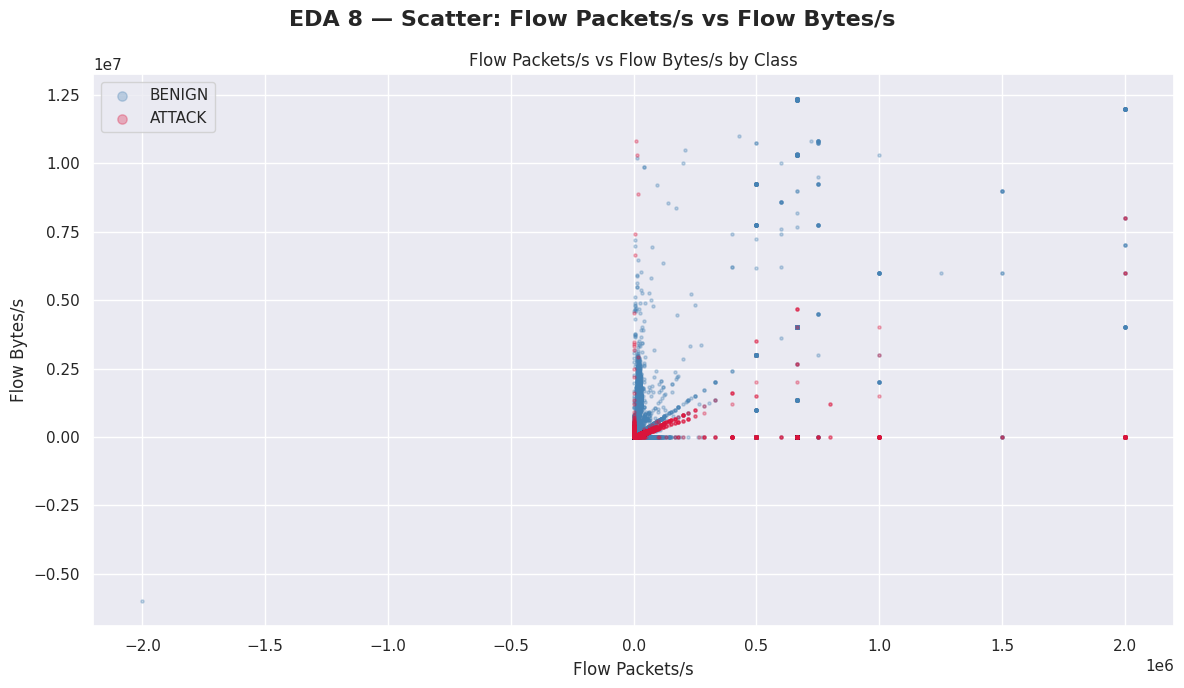

EDA 8 complete.


In [16]:
# ── EDA 8: Scatter — Flow Packets/s vs Flow Bytes/s ──────────────────────
scatter_df = df[['Flow Packets/s', 'Flow Bytes/s', 'binary_label']].replace(
    [np.inf, -np.inf], np.nan).dropna()
scatter_df = scatter_df[
    (scatter_df['Flow Packets/s'] <= scatter_df['Flow Packets/s'].quantile(0.99)) &
    (scatter_df['Flow Bytes/s'] <= scatter_df['Flow Bytes/s'].quantile(0.99))
].sample(min(20000, len(scatter_df)), random_state=42)

scatter_df['Label'] = scatter_df['binary_label'].map({0: 'BENIGN', 1: 'ATTACK'})

fig, ax = plt.subplots(figsize=(12, 7))
fig.suptitle('EDA 8 — Scatter: Flow Packets/s vs Flow Bytes/s', fontsize=16, fontweight='bold')

for lbl, color in [('BENIGN', 'steelblue'), ('ATTACK', 'crimson')]:
    subset = scatter_df[scatter_df['Label'] == lbl]
    ax.scatter(subset['Flow Packets/s'], subset['Flow Bytes/s'],
               c=color, label=lbl, alpha=0.3, s=5)

ax.set_xlabel('Flow Packets/s')
ax.set_ylabel('Flow Bytes/s')
ax.legend(markerscale=3)
ax.set_title('Flow Packets/s vs Flow Bytes/s by Class')

plt.tight_layout()
plt.savefig(os.path.join(PLOT_DIR, 'eda_08_scatter_packets_bytes.png'), dpi=150, bbox_inches='tight')
plt.show()
print('EDA 8 complete.')

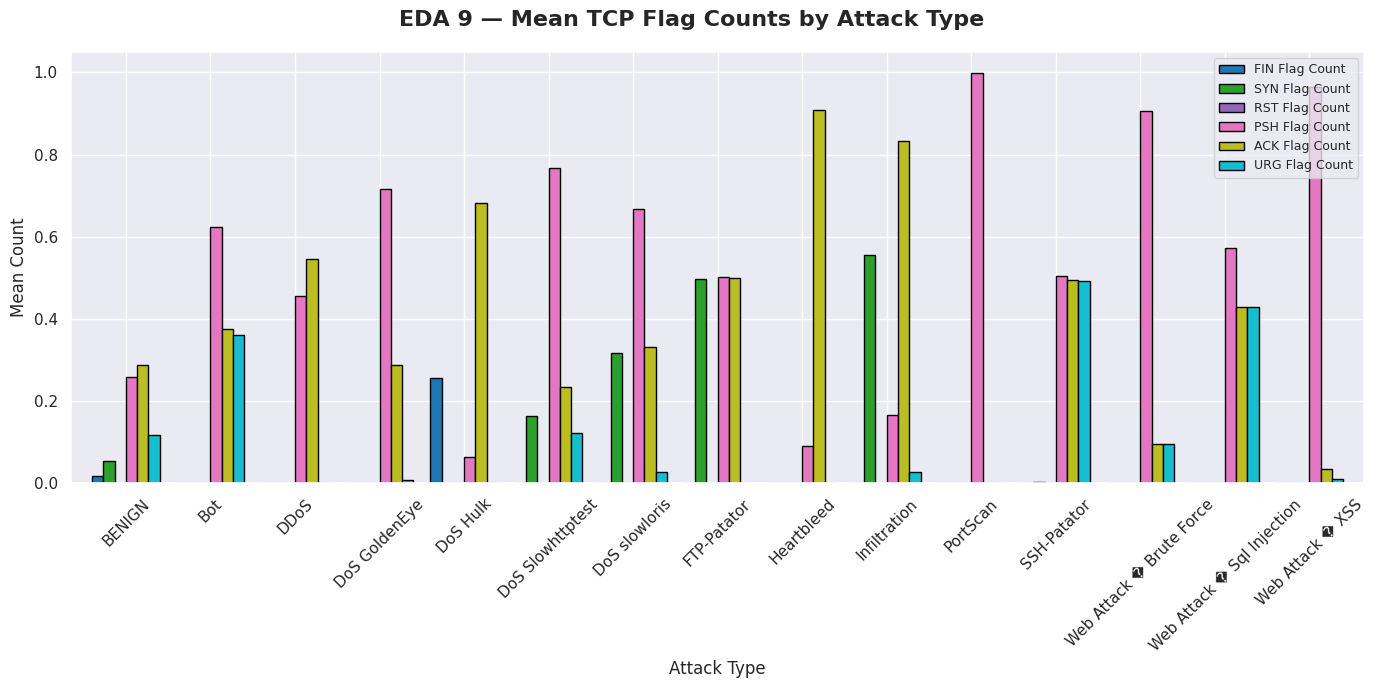

EDA 9 complete.


In [17]:
# ── EDA 9: TCP Flag Counts by Attack Type ────────────────────────────────
flag_cols = [c for c in ['FIN Flag Count', 'SYN Flag Count', 'RST Flag Count',
                          'PSH Flag Count', 'ACK Flag Count', 'URG Flag Count'] if c in df.columns]

flag_df = df[flag_cols + ['Label']].groupby('Label')[flag_cols].mean().reset_index()
flag_df = flag_df.set_index('Label')

fig, ax = plt.subplots(figsize=(14, 7))
fig.suptitle('EDA 9 — Mean TCP Flag Counts by Attack Type', fontsize=16, fontweight='bold')

flag_df.plot(kind='bar', ax=ax, colormap='tab10', edgecolor='black', width=0.8)
ax.set_xlabel('Attack Type')
ax.set_ylabel('Mean Count')
ax.tick_params(axis='x', rotation=45)
ax.legend(loc='upper right', fontsize=9)

plt.tight_layout()
plt.savefig(os.path.join(PLOT_DIR, 'eda_09_tcp_flags.png'), dpi=150, bbox_inches='tight')
plt.show()
print('EDA 9 complete.')

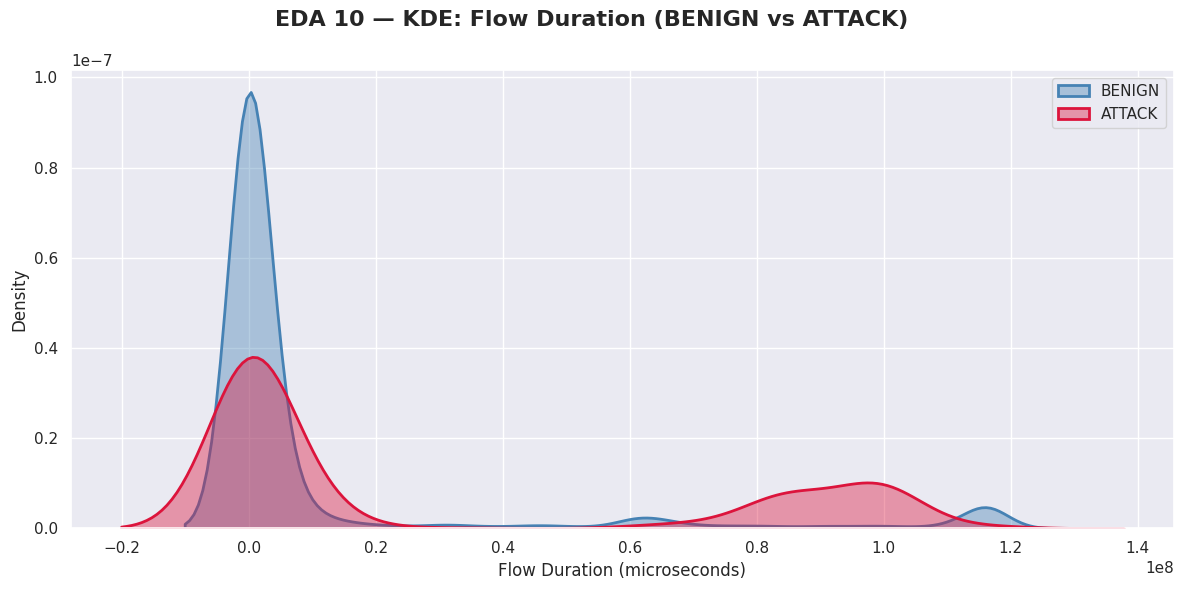

EDA 10 complete.


In [18]:
# ── EDA 10: KDE — Flow Duration (BENIGN vs ATTACK) ────────────────────────
kde_df = df[['Flow Duration', 'binary_label']].replace([np.inf, -np.inf], np.nan).dropna()
upper = kde_df['Flow Duration'].quantile(0.99)
kde_df = kde_df[kde_df['Flow Duration'] <= upper].sample(min(50000, len(kde_df)), random_state=42)

fig, ax = plt.subplots(figsize=(12, 6))
fig.suptitle('EDA 10 — KDE: Flow Duration (BENIGN vs ATTACK)', fontsize=16, fontweight='bold')

for val, lbl, color in [(0, 'BENIGN', 'steelblue'), (1, 'ATTACK', 'crimson')]:
    subset = kde_df[kde_df['binary_label'] == val]['Flow Duration']
    sns.kdeplot(subset, ax=ax, label=lbl, color=color, fill=True, alpha=0.4, linewidth=2)

ax.set_xlabel('Flow Duration (microseconds)')
ax.set_ylabel('Density')
ax.legend()

plt.tight_layout()
plt.savefig(os.path.join(PLOT_DIR, 'eda_10_kde_flow_duration.png'), dpi=150, bbox_inches='tight')
plt.show()
print('EDA 10 complete.')

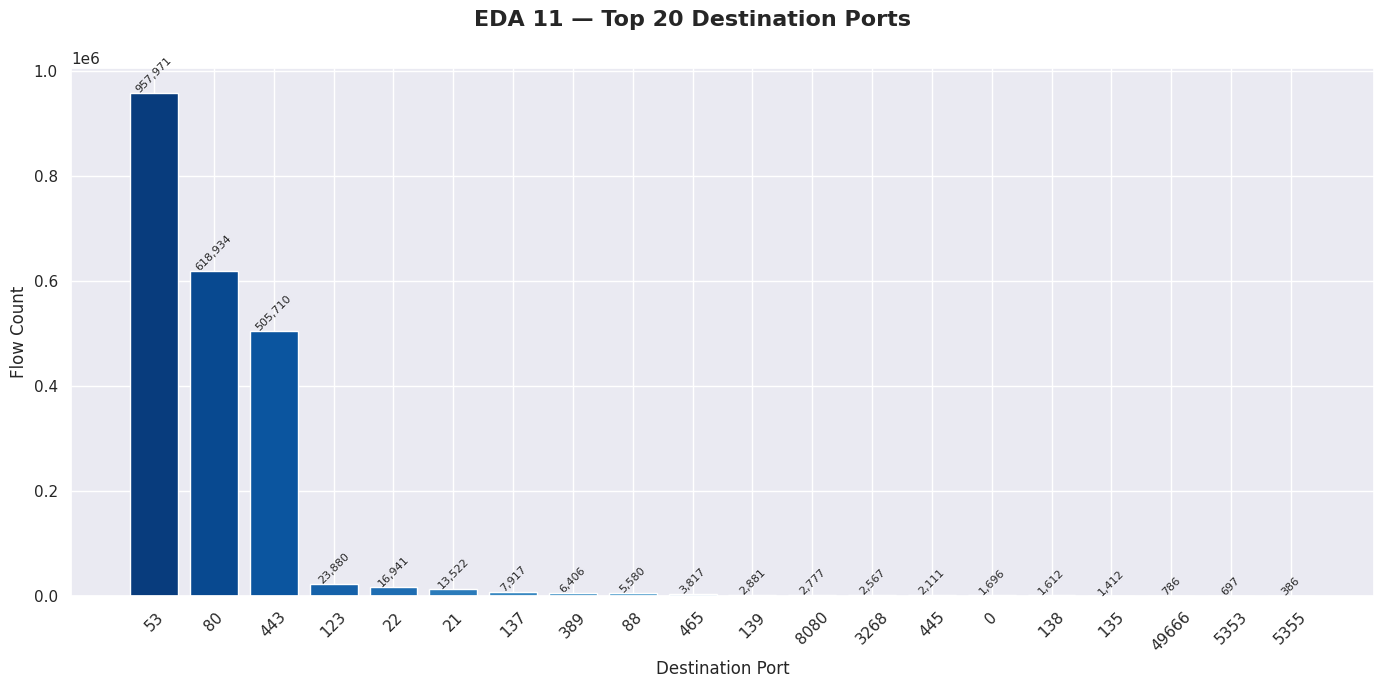

EDA 11 complete.


In [19]:
# ── EDA 11: Top 20 Destination Ports ─────────────────────────────────────
port_col = 'Destination Port' if 'Destination Port' in df.columns else 'Dst Port'

if port_col in df.columns:
    top_ports = df[port_col].value_counts().head(20)
    fig, ax = plt.subplots(figsize=(14, 7))
    fig.suptitle('EDA 11 — Top 20 Destination Ports', fontsize=16, fontweight='bold')
    ax.bar(top_ports.index.astype(str), top_ports.values,
           color=sns.color_palette('Blues_r', len(top_ports)))
    ax.set_xlabel('Destination Port')
    ax.set_ylabel('Flow Count')
    ax.tick_params(axis='x', rotation=45)
    for i, v in enumerate(top_ports.values):
        ax.text(i, v + 500, f'{v:,}', ha='center', fontsize=8, rotation=45)
    plt.tight_layout()
    plt.savefig(os.path.join(PLOT_DIR, 'eda_11_top_ports.png'), dpi=150, bbox_inches='tight')
    plt.show()
else:
    print(f"Port column '{port_col}' not found in dataframe.")
print('EDA 11 complete.')

<Figure size 1600x1400 with 0 Axes>

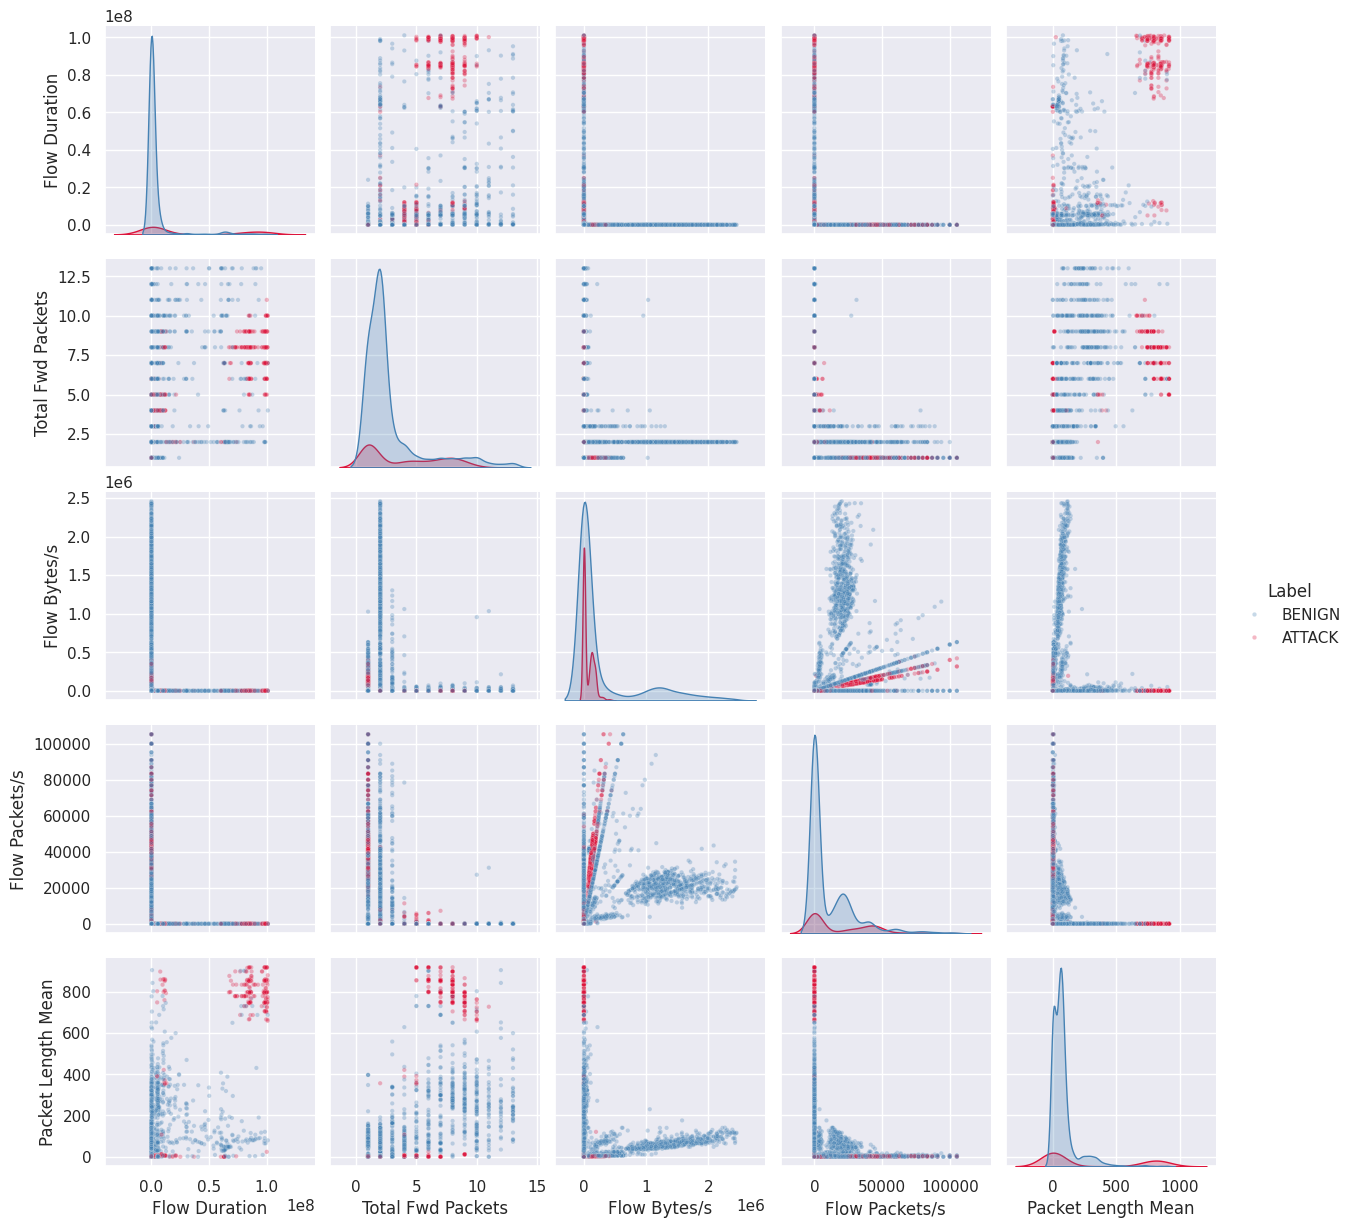

EDA 12 complete.


In [20]:
# ── EDA 12: Pairplot of Key Features ─────────────────────────────────────
pair_feats = [f for f in [
    'Flow Duration', 'Total Fwd Packets', 'Flow Bytes/s',
    'Flow Packets/s', 'Packet Length Mean'
] if f in df.columns]

pair_df = df[pair_feats + ['binary_label']].replace([np.inf, -np.inf], np.nan).dropna()
for col in pair_feats:
    upper = pair_df[col].quantile(0.95)
    pair_df = pair_df[pair_df[col] <= upper]
pair_df = pair_df.sample(min(5000, len(pair_df)), random_state=42)
pair_df['Label'] = pair_df['binary_label'].map({0: 'BENIGN', 1: 'ATTACK'})

fig = plt.figure(figsize=(16, 14))
fig.suptitle('EDA 12 — Pairplot of Key Features', fontsize=16, fontweight='bold', y=1.01)
pg = sns.pairplot(pair_df[pair_feats + ['Label']], hue='Label',
                  palette={'BENIGN': 'steelblue', 'ATTACK': 'crimson'},
                  plot_kws={'alpha': 0.3, 's': 10},
                  diag_kind='kde')
pg.savefig(os.path.join(PLOT_DIR, 'eda_12_pairplot.png'), dpi=120, bbox_inches='tight')
plt.show()
print('EDA 12 complete.')

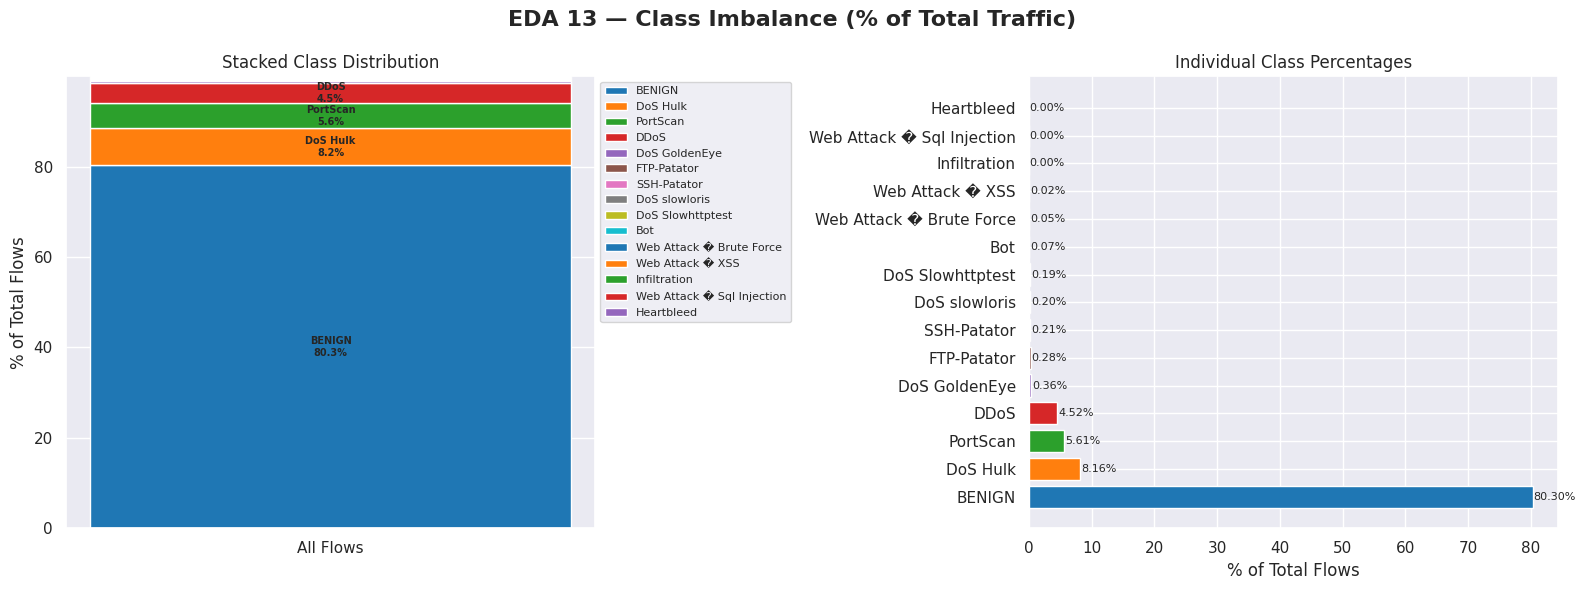

EDA 13 complete.


In [22]:
# ── EDA 13: Class Imbalance Stacked Bar (% of Total) ─────────────────────
total = len(df)
attack_pct = df.groupby('Label').size() / total * 100
attack_pct = attack_pct.sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('EDA 13 — Class Imbalance (% of Total Traffic)', fontsize=16, fontweight='bold')

# Stacked bar
cumulative = 0
colors = sns.color_palette('tab10', len(attack_pct))
for i, (label, pct) in enumerate(attack_pct.items()):
    axes[0].bar('All Flows', pct, bottom=cumulative, color=colors[i], label=label, edgecolor='white')
    if pct > 1:
        axes[0].text(0, cumulative + pct/2, f'{label}\n{pct:.1f}%', ha='center', va='center', fontsize=7, fontweight='bold')
    cumulative += pct
axes[0].set_ylabel('% of Total Flows')
axes[0].set_title('Stacked Class Distribution')
axes[0].legend(loc='upper left', bbox_to_anchor=(1, 1), fontsize=8)

# Horizontal bar (sorted)
axes[1].barh(attack_pct.index, attack_pct.values, color=colors)
axes[1].set_xlabel('% of Total Flows')
axes[1].set_title('Individual Class Percentages')
for i, v in enumerate(attack_pct.values):
    axes[1].text(v + 0.1, i, f'{v:.2f}%', va='center', fontsize=8)

plt.tight_layout()
plt.savefig(os.path.join(PLOT_DIR, 'eda_13_class_imbalance.png'), dpi=150, bbox_inches='tight')
plt.show()
print('EDA 13 complete.')

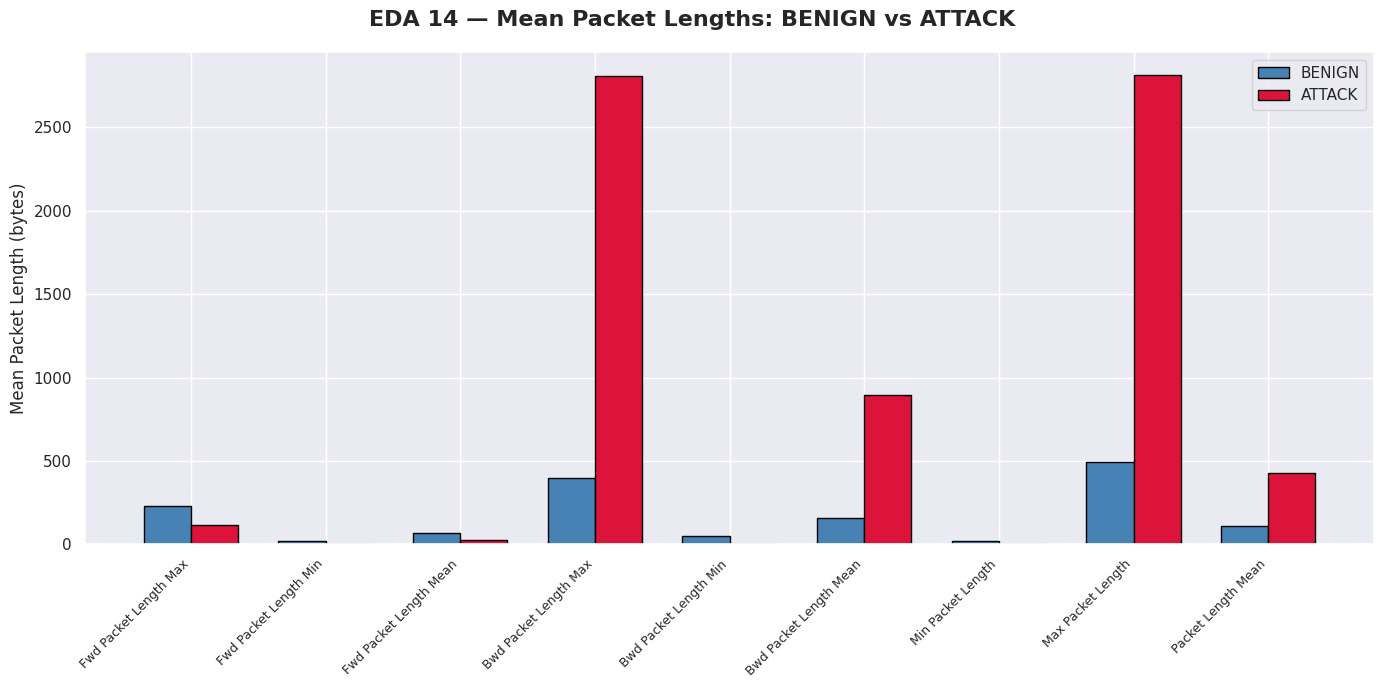

EDA 14 complete.


In [23]:
# ── EDA 14: Mean Packet Lengths — BENIGN vs ATTACK ────────────────────────
pkt_cols = [c for c in [
    'Fwd Packet Length Max', 'Fwd Packet Length Min', 'Fwd Packet Length Mean',
    'Bwd Packet Length Max', 'Bwd Packet Length Min', 'Bwd Packet Length Mean',
    'Min Packet Length', 'Max Packet Length', 'Packet Length Mean'
] if c in df.columns]

pkt_df = df[pkt_cols + ['binary_label']].replace([np.inf, -np.inf], np.nan).dropna()
pkt_means = pkt_df.groupby('binary_label')[pkt_cols].mean().T
pkt_means.columns = ['BENIGN', 'ATTACK']

fig, ax = plt.subplots(figsize=(14, 7))
fig.suptitle('EDA 14 — Mean Packet Lengths: BENIGN vs ATTACK', fontsize=16, fontweight='bold')

x = np.arange(len(pkt_cols))
width = 0.35
ax.bar(x - width/2, pkt_means['BENIGN'], width, label='BENIGN', color='steelblue', edgecolor='black')
ax.bar(x + width/2, pkt_means['ATTACK'], width, label='ATTACK', color='crimson', edgecolor='black')
ax.set_xticks(x)
ax.set_xticklabels(pkt_cols, rotation=45, ha='right', fontsize=9)
ax.set_ylabel('Mean Packet Length (bytes)')
ax.legend()

plt.tight_layout()
plt.savefig(os.path.join(PLOT_DIR, 'eda_14_packet_lengths.png'), dpi=150, bbox_inches='tight')
plt.show()
print('EDA 14 complete.')

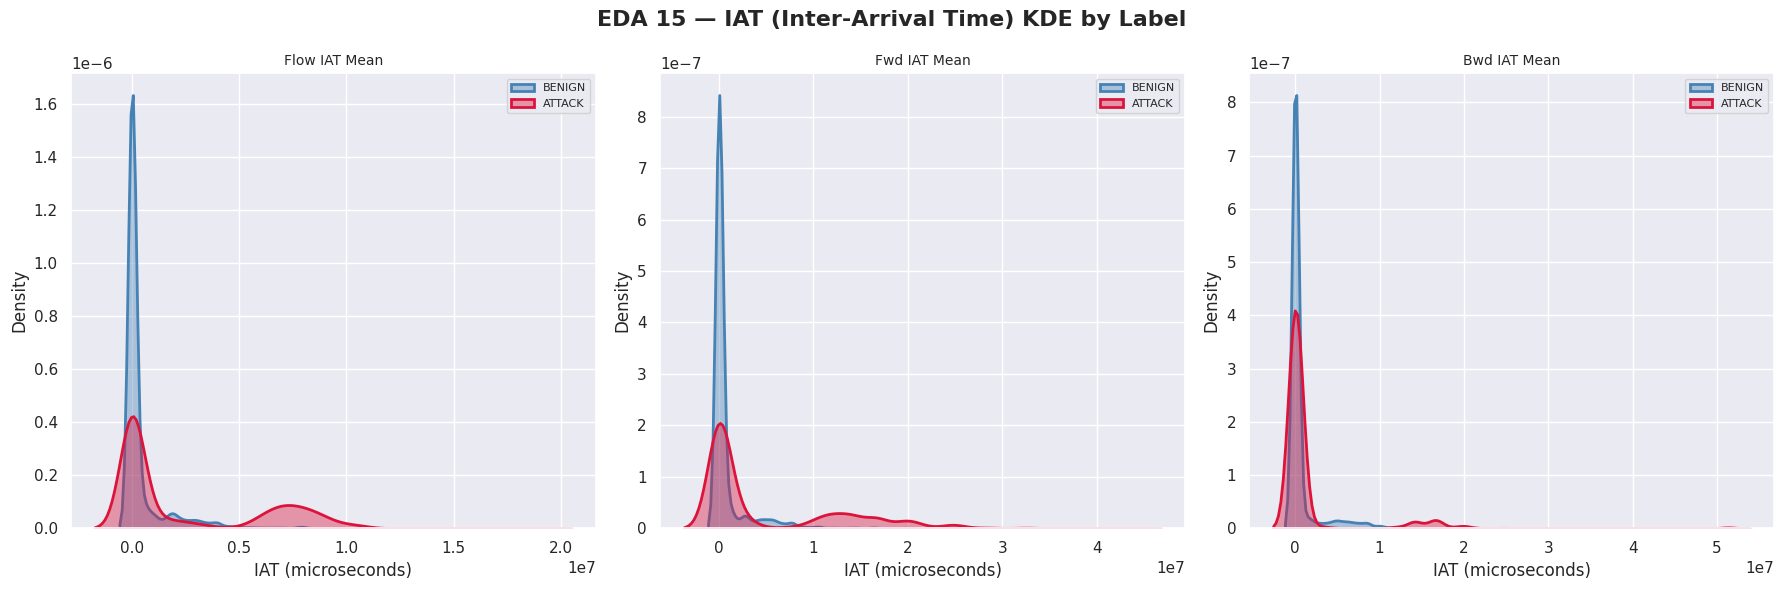


=== ALL 15 EDA VISUALISATIONS COMPLETE ===
Plots saved to: /kaggle/working/eda_plots


In [24]:
# ── EDA 15: IAT (Inter-Arrival Time) KDE by Label ────────────────────────
iat_cols = [c for c in [
    'Flow IAT Mean', 'Fwd IAT Mean', 'Bwd IAT Mean'
] if c in df.columns]

iat_sample = df[iat_cols + ['binary_label']].replace([np.inf, -np.inf], np.nan).dropna()
iat_sample = iat_sample.sample(min(50000, len(iat_sample)), random_state=42)
iat_sample['Label'] = iat_sample['binary_label'].map({0: 'BENIGN', 1: 'ATTACK'})

fig, axes = plt.subplots(1, len(iat_cols), figsize=(18, 6))
fig.suptitle('EDA 15 — IAT (Inter-Arrival Time) KDE by Label', fontsize=16, fontweight='bold')

if len(iat_cols) == 1:
    axes = [axes]

for ax, col in zip(axes, iat_cols):
    upper = iat_sample[col].quantile(0.99)
    tmp = iat_sample[iat_sample[col] <= upper]
    for lbl, color in [('BENIGN', 'steelblue'), ('ATTACK', 'crimson')]:
        subset = tmp[tmp['Label'] == lbl][col]
        sns.kdeplot(subset, ax=ax, label=lbl, color=color, fill=True, alpha=0.4, linewidth=2)
    ax.set_title(col, fontsize=10)
    ax.set_xlabel('IAT (microseconds)')
    ax.set_ylabel('Density')
    ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig(os.path.join(PLOT_DIR, 'eda_15_iat_kde.png'), dpi=150, bbox_inches='tight')
plt.show()

print('\n=== ALL 15 EDA VISUALISATIONS COMPLETE ===')
print(f'Plots saved to: {PLOT_DIR}')